In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [2]:
features = pd.read_excel("smartphone_battery_features.xlsx")
targets = pd.read_excel("smartphone_battery_targets.xlsx")

print("Features:", features.shape)
print("Targets:", targets.shape)

Features: (5000, 19)
Targets: (5000, 3)


In [3]:
df = pd.merge(features, targets, on="Device_ID")

print("Merged data:", df.shape)

Merged data: (5000, 21)


In [4]:
X = df[[
    "device_age_months",
    "overnight_charging_freq_per_week",
    "video_streaming_hours_per_week",
    "gaming_hours_per_week",
    "avg_screen_on_hours_per_day"
]]

y = df["current_battery_health_percent"]

X.head()

,device_age_months,overnight_charging_freq_per_week,video_streaming_hours_per_week,gaming_hours_per_week,avg_screen_on_hours_per_day
0,38,7,14.0,7.9,7.1
1,28,2,11.0,8.6,6.8
2,14,4,10.3,0.3,7.2
3,42,0,4.9,1.9,5.5
4,7,6,9.3,7.9,7.6


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 3500
Testing data: 1500


In [6]:
model = XGBRegressor(random_state=42)

model.fit(X_train, y_train)

print("XGBoost training complete")

XGBoost training complete


In [7]:
y_pred = model.predict(X_test)

print("Prediction complete")

Prediction complete


In [8]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", round(r2, 4))
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

R²: 0.901
MAE: 4.43
RMSE: 5.56


In [9]:
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    "Importance", ascending=False
)

xgb_importance

,Feature,Importance
0,device_age_months,0.740487
4,avg_screen_on_hours_per_day,0.207764
1,overnight_charging_freq_per_week,0.022581
3,gaming_hours_per_week,0.014982
2,video_streaming_hours_per_week,0.014186


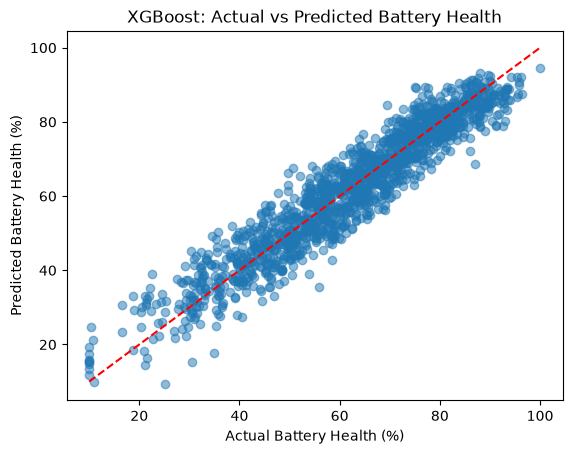

In [10]:
plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual Battery Health (%)")
plt.ylabel("Predicted Battery Health (%)")
plt.title("XGBoost: Actual vs Predicted Battery Health")

plt.show()

In [11]:
from sklearn.model_selection import cross_val_score

cv_r2 = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("R² for each fold:", cv_r2.round(4))
print("Average R²:", round(cv_r2.mean(), 4))
print("Standard deviation:", round(cv_r2.std(), 4))

R² for each fold: [0.8954 0.9039 0.9046 0.9072 0.9026]
Average R²: 0.9027
Standard deviation: 0.004


All 5,000 are divided into 5 groups of about 1,000
Each round: about 4,000 train + 1,000 test
Repeat 5 times, so every data point is used for testing once.
same for MAE and RMSE

In [12]:
cv_mae = -cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="neg_mean_absolute_error"
)

cv_rmse = -cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

print("Average MAE:", round(cv_mae.mean(), 2))
print("Average RMSE:", round(cv_rmse.mean(), 2))

Average MAE: 4.37
Average RMSE: 5.52
